# Text Classification

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## The Pipeline

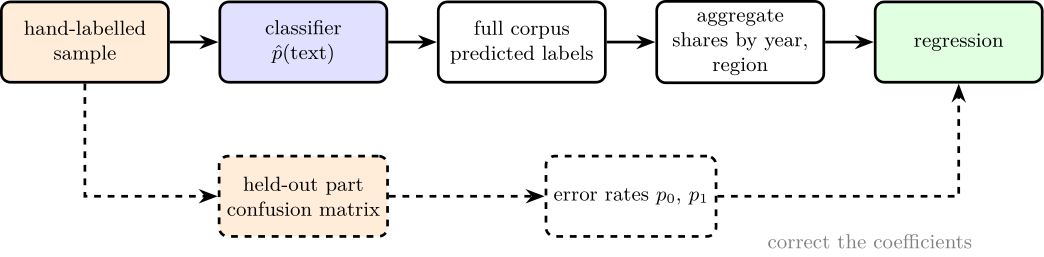

- The classification lecture coded job titles; this one builds variables from **text**: the sentiment of a sentence, the topic of a news article. The top row is what ML tutorials cover, the dashed row is what makes the result usable as economics
- Running example: [Newswire](https://huggingface.co/datasets/dell-research-harvard/newswire), $2.7$ million wire-service articles from $1878$ to $1977$ with topic labels (Silcock, Arora, D’Amico-Wong, and Dell 2024)

## Extra Materials

- [Gentzkow, Kelly, and Taddy (2019), “Text as Data”](https://www.aeaweb.org/articles?id=10.1257/jel.20181020), *JEL*
- [Ash and Hansen (2023), “Text Algorithms in Economics”](https://doi.org/10.1146/annurev-economics-082222-074352), *Annual Review of Economics*
- [Dell (2025), “Deep Learning for Economists”](https://www.aeaweb.org/articles?id=10.1257/jel.20241733), *JEL*, and [EconDL](https://econdl.github.io/), in particular the [topic and sentiment classification](https://econdl.github.io/intro/2023/03/22/lecture14.html) lecture
- [Silcock, Arora, D’Amico-Wong, and Dell (2024), “Newswire”](https://arxiv.org/abs/2406.09490) and the [dataset on the Hugging Face Hub](https://huggingface.co/datasets/dell-research-harvard/newswire)
- [Shapiro, Sudhof, and Wilson (2022), “Measuring News Sentiment”](https://doi.org/10.1016/j.jeconom.2020.07.053), *Journal of Econometrics*
- [Loughran and McDonald (2011), “When Is a Liability Not a Liability?”](https://doi.org/10.1111/j.1540-6261.2010.01625.x), *Journal of Finance*, the standard finance sentiment lexicon
- [Battaglia, Christensen, Hansen, and Sacher (2024), “Inference for Regression with Variables Generated by AI or Machine Learning”](https://arxiv.org/abs/2402.15585)

## Packages

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import statsmodels.formula.api as smf

- The optional sections at the end also use `langchain_openai` (as in the NLP lecture) and `huggingface_hub`

# Text as Features

## From Documents to Vectors

- Three ways to turn a document into $x_n \in {\mathbb{R}}^M$
  1.  **Bag of words**: count each vocabulary word. Sparse, interpretable, ignores order
  2.  **TF-IDF**: the same counts, reweighted so that words common to every document count less
  3.  **Embeddings**: a dense vector from a language model, as in the NLP lecture. Captures meaning at the cost of an API call
- With term frequency $\text{tf}_{n,j}$ and document frequency $\text{df}_j$ over $N$ documents,

$$
x_{n,j} = \text{tf}_{n,j} \cdot \text{idf}_j, \qquad \text{idf}_j = \log \frac{1 + N}{1 + \text{df}_j} + 1
$$

- `TfidfVectorizer` normalizes rows to unit length; `sublinear_tf=True`, `stop_words="english"`, and `min_df=5` tame counts and vocabulary

## Where Do Labels Come From?

- Somebody reads a **random sample** of documents and labels each one. That is the expensive step; two coders on a subset measure how vague the definition is
- Random from the corpus, so the classifier’s error rates on the held-out part are its error rates on the corpus: the sample is both the training set and the confusion matrix
- An LLM can produce first-pass labels and people check a subset. What matters is still the error rate against a human-coded random sample

# A Simple Sentiment Measure

## Financial PhraseBank

- $2{,}264$ sentences from financial news, labelled positive, negative, or neutral by annotators who all agreed (Malo et al. 2014)

In [4]:
def data_path(name):
    url = "https://jlperla.github.io/grad_econ_datascience/slides/data/"
    return f"data/{name}" if os.path.exists(f"data/{name}") else url + name

phrases = pd.read_csv(data_path("financial_phrasebank.csv.gz"))
print(phrases["label"].value_counts())
for _, row in phrases.sample(3, random_state=3).iterrows():
    print(f"[{row['label']}] {row['sentence'][:90]}")

label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64
[neutral] LCS 's services cover the whole life cycle of software and information systems , from proc
[negative] The company 's profit before taxes fell to EUR 21.1 mn in the third quarter of 2008 , comp
[positive] EPS from continuing operations came in at 0.30 eur , up from 0.17 .

## A Lexicon Score

- The oldest approach: positive count minus negative count from hand-written word lists, no training data

In [5]:
positive = ["profit", "increase", "increased", "rose", "growth", "higher",
            "improved", "gain", "record", "strong", "up"]
negative = ["loss", "losses", "decrease", "decreased", "fell", "lower",
            "decline", "cut", "weak", "drop", "down"]
n_pos = CountVectorizer(vocabulary=positive).transform(phrases["sentence"]).sum(axis=1)
n_neg = CountVectorizer(vocabulary=negative).transform(phrases["sentence"]).sum(axis=1)
score = np.asarray(n_pos - n_neg).ravel()
phrases["lexicon"] = np.select([score > 0, score < 0], ["positive", "negative"],
                               default="neutral")
print(pd.crosstab(phrases["label"], phrases["lexicon"]))

lexicon   negative  neutral  positive
label                                
negative       118      163        22
neutral          5     1326        60
positive        29      225       316

- Rows are the human label. The lexicon finds many positives but calls most negative sentences neutral: financial news says “decreased” in many ways

## A Trained Sentiment Classifier

- Same sentences, TF-IDF features, multinomial logistic regression, a held-out quarter

In [6]:
train, test = train_test_split(phrases, test_size=0.25, random_state=526)
vec_fpb = TfidfVectorizer(min_df=2, sublinear_tf=True)
sentiment = LogisticRegression(max_iter=1000).fit(
    vec_fpb.fit_transform(train["sentence"]), train["label"])
pred = sentiment.predict(vec_fpb.transform(test["sentence"]))
print(classification_report(test["label"], pred, digits=2))

              precision    recall  f1-score   support

    negative       0.85      0.52      0.65        79
     neutral       0.83      0.99      0.90       341
    positive       0.86      0.66      0.74       146

    accuracy                           0.84       566
   macro avg       0.85      0.72      0.76       566
weighted avg       0.84      0.84      0.83       566


- $1{,}700$ labelled sentences beat the hand-written lexicon on every class

## The Learned Lexicon

- The largest coefficients per class are the words that push hardest toward that class

In [7]:
coef = pd.DataFrame(sentiment.coef_.T, index=vec_fpb.get_feature_names_out(),
                    columns=sentiment.classes_)
print({k: list(coef[k].nlargest(6).index) for k in coef.columns})

{'negative': ['decreased', 'down', 'fell', 'loss', 'dropped', 'by'], 'neutral': ['is', 'be', 'and', 'will', 'not', 'the'], 'positive': ['rose', 'increased', 'up', 'increase', 'grew', 'from']}

- The negative and positive lists are what a person would write, plus forms the hand list missed. Neutral is function words: what remains when nothing directional is said

# Newswire: A Century of Wire Stories

## The Dataset

- Local papers ran wire-service stories (AP, UP, INS). Silcock, Arora, D’Amico-Wong, and Dell (2024) found them on scanned pages, deduplicated the copies, and released $2.7$ million articles, $1878$ to $1977$, with the newspapers that ran each one and their states
- **Seven topic flags** (politics, civil rights, labor movement, antitrust, government regulation, protests, crime) from RoBERTa classifiers trained on hand-labelled articles: about $2{,}400$ for politics, $940$ for civil rights, $250$ for labor movement, F1 between $85$ and $94$
- We treat the flags as labels. They are classifier output distilled from human labels, so our classifier learns to imitate a model. [Hub page](https://huggingface.co/datasets/dell-research-harvard/newswire), DOI `10.57967/hf/2423`, CC BY 4.0

## Our Sample

- The yearly files total $35$ GB, so the course repository holds a stratified sample, $400$ articles per year for $1947$ to $1977$ and $40$ per year for $1900$ to $1946$, drawn by reading random byte windows of each file (the Hub section shows how)
- Four caveats
  1.  Records straddling a window edge are dropped, so very long articles are slightly under-sampled
  2.  `paper_states` lists which newspapers **carried** a wire story: regional differences are differential carrying, not local production
  3.  The topic flags are model output, not human coding
  4.  Years have fixed counts, so pooled means are not corpus-representative. Report by year

## Base Rates by Year

In [8]:
news = pd.read_csv(data_path("newswire_sample.csv.gz"))
topics = ["politics", "civil_rights", "labor_movement", "crime"]
by_year = news.groupby("year")[topics].mean()
print(by_year.loc[[1920, 1940, 1950, 1955, 1960, 1965, 1970, 1977]].round(3))

      politics  civil_rights  labor_movement  crime
year                                               
1920     0.350         0.000           0.350  0.125
1940     0.450         0.000           0.050  0.075
1950     0.318         0.002           0.098  0.108
1955     0.335         0.008           0.085  0.132
1960     0.378         0.055           0.058  0.122
1965     0.288         0.058           0.070  0.095
1970     0.335         0.042           0.052  0.120
1977     0.435         0.015           0.075  0.125

- Politics is a third or more of the wire in every year. Civil rights is under one percent in the early 1950s and about six percent by the mid 1960s
- Labor movement sits between five and ten percent after 1947 with no trend, the cleaner target to learn. The 1920 figure is $40$ articles in a strike wave

## Coverage over the Century

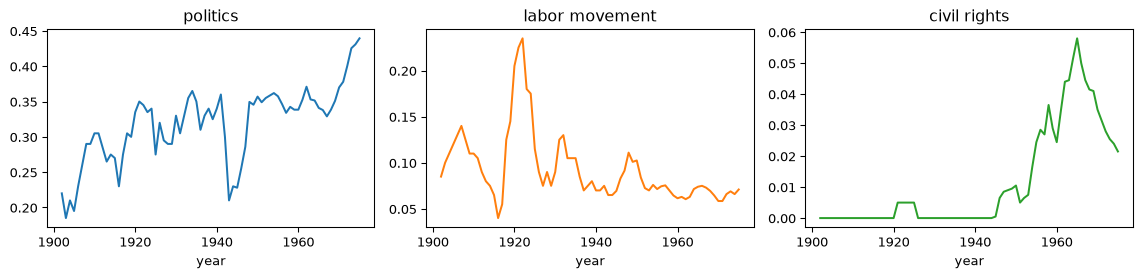

In [9]:
smooth = by_year[["politics", "labor_movement", "civil_rights"]].rolling(
    5, center=True).mean()
smooth.plot(subplots=True, layout=(1, 3), figsize=(12, 3.0), legend=False,
            title=["politics", "labor movement", "civil rights"])
plt.tight_layout()
plt.show()

- Five-year centered moving averages. The pre-1947 years have $40$ articles each, so the early series are noisy

# Training a Topic Classifier

## Features and Split

- TF-IDF on the article text, a quarter of the articles held out. The vocabulary and the document frequencies come from the training part only, so the held-out quarter never touches the fit

In [10]:
train_idx, test_idx = train_test_split(np.arange(len(news)), test_size=0.25,
                                       random_state=526)
vec = TfidfVectorizer(min_df=5, stop_words="english", sublinear_tf=True)
vec.fit(news["text"].iloc[train_idx])
X = vec.transform(news["text"])
X_tr, X_te = X[train_idx], X[test_idx]
print(f"{X.shape[0]} articles, {X.shape[1]} words, "
      f"{len(train_idx)} train, {len(test_idx)} test")

14280 articles, 15340 words, 10710 train, 3570 test

## Labor Movement: the Default Fit

In [11]:
y_tr = news["labor_movement"].iloc[train_idx]
y_te = news["labor_movement"].iloc[test_idx]
labor = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print(confusion_matrix(y_te, labor.predict(X_te)))
print(classification_report(y_te, labor.predict(X_te), digits=2))

[[3296    0]
 [ 157  117]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3296
           1       1.00      0.43      0.60       274

    accuracy                           0.96      3570
   macro avg       0.98      0.71      0.79      3570
weighted avg       0.96      0.96      0.95      3570


- Perfect precision, poor recall: with $8\%$ positives the penalized fit is conservative and misses most labor stories

## Rebalancing the Classes

- `class_weight="balanced"` reweights the log-likelihood so both classes carry equal total weight, which pushes the fitted probabilities toward the rare class

In [12]:
labor = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_tr, y_tr)
print(confusion_matrix(y_te, labor.predict(X_te)))
print(classification_report(y_te, labor.predict(X_te), digits=2))

[[3226   70]
 [  64  210]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3296
           1       0.75      0.77      0.76       274

    accuracy                           0.96      3570
   macro avg       0.87      0.87      0.87      3570
weighted avg       0.96      0.96      0.96      3570


- Precision falls, recall nearly doubles: the cost argument from the classification lecture

## What the Classifier Learned

In [13]:
weights = pd.Series(labor.coef_[0], index=vec.get_feature_names_out())
print(list(weights.nlargest(15).index))
print(list(weights.nsmallest(8).index))

['strike', 'union', 'labor', 'workers', 'association', 'cio', 'afl', 'contract', 'negotiations', 'wage', 'unions', 'agreement', 'coal', 'protest', 'premier']
['ap', 'eisenhower', 'soviet', 'military', 'nixon', 'states', 'american', 'old']

- The largest positive weights are the vocabulary of a strike story; the most negative are the rest of the wire: presidents, the Cold War, and the `AP` byline

## Civil Rights

- Rarer ($2.5\%$ overall, $3$ to $6\%$ in the years that matter) and the outcome of the first regression, so balanced weights from the start

In [14]:
y_tr = news["civil_rights"].iloc[train_idx]
y_te = news["civil_rights"].iloc[test_idx]
civil = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_tr, y_tr)
print(confusion_matrix(y_te, civil.predict(X_te)))
print(classification_report(y_te, civil.predict(X_te), digits=2))

[[3459   26]
 [   7   78]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3485
           1       0.75      0.92      0.83        85

    accuracy                           0.99      3570
   macro avg       0.87      0.96      0.91      3570
weighted avg       0.99      0.99      0.99      3570


## Cross-Fitting

- The regression wants a prediction for **every** article, but predictions on training articles are far too good. **Cross-fitting** predicts each of $K$ folds with a model trained on the other $K - 1$, so every article is predicted by a model that never saw its label, and the confusion matrix of the result is out of sample
- `cross_val_predict` does it in one call. The same idea underlies double machine learning

In [15]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
news["civil_rights_hat"] = cross_val_predict(model, X, news["civil_rights"],
                                             cv=5, n_jobs=-1)
print(confusion_matrix(news["civil_rights"], news["civil_rights_hat"]))

[[13853    77]
 [   62   288]]

# Coverage Regressions

## Civil Rights Coverage in the South

- Did papers in the former Confederacy carry more or less civil rights news than the rest of the country between $1954$ (*Brown*) and $1968$? The unit is an article $\times$ newspaper pair, one `explode` of `paper_states`

In [16]:
south = ["alabama", "arkansas", "florida", "georgia", "louisiana",
         "mississippi", "north carolina", "south carolina", "tennessee",
         "texas", "virginia"]
era = news[news["year"].between(1954, 1968)]
panel = era.assign(state=era["paper_states"].str.split(";")).explode("state")
panel["south"] = panel["state"].isin(south).astype(int)
print(f"{len(era)} articles, {len(panel)} article-newspaper pairs, "
      f"{panel['state'].nunique()} states, south share {panel['south'].mean():.2f}")

6000 articles, 85448 article-newspaper pairs, 47 states, south share 0.20

## The Regression, Twice

- Outcome: the civil rights flag, then our cross-fitted prediction of it. Regressors: the South indicator and year effects, standard errors clustered by state

In [17]:
def south_effect(outcome):
    fit = smf.ols(f"{outcome} ~ south + C(year)", data=panel).fit(
        cov_type="cluster", cov_kwds={"groups": panel["state"]})
    return fit.params["south"], fit.bse["south"]

results = pd.DataFrame([south_effect("civil_rights"),
                        south_effect("civil_rights_hat")],
                       index=["Newswire label", "our classifier"],
                       columns=["south", "se"])
print(results.round(4))

                 south      se
Newswire label  0.0175  0.0038
our classifier  0.0180  0.0036

- Southern papers carried civil rights stories about $1.8$ percentage points more often, on a base of about $4\%$. The generated outcome gives nearly the same answer; we return to why below

## Labor Coverage and Strikes

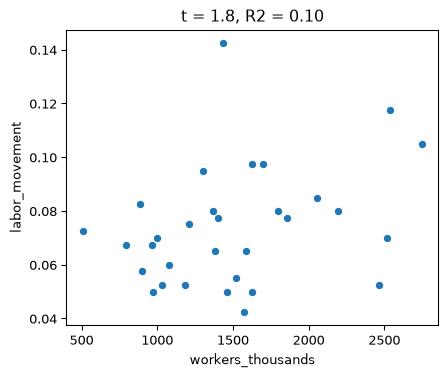

In [18]:
strikes = pd.read_csv(data_path("work_stoppages.csv"))
yearly = news[news["year"] >= 1947].groupby("year")[
    "labor_movement"].mean().to_frame()
yearly = yearly.join(strikes.set_index("year"))
fit = smf.ols("labor_movement ~ workers_thousands",
              data=yearly).fit()
ax = yearly.plot.scatter(x="workers_thousands",
                         y="labor_movement",
                         figsize=(5, 4))
ax.set_title(f"t = {fit.tvalues.iloc[1]:.1f}, "
             f"R2 = {fit.rsquared:.2f}")
plt.show()

- Yearly share of labor stories against workers in major BLS work stoppages, $1947$ to $1977$. Weak: wire coverage follows particular disputes (steel in 1952 and 1959, coal in 1949), not the volume of strikes
- Each share comes from $400$ articles, so it carries about a point of sampling noise, which lowers $R^2$ without biasing the slope

# Measurement Error in the Outcome

## Misclassifying the Dependent Variable

- The regression outcome is the classifier’s $\tilde{y}_n$, not the true $y_n$. With false positive rate $p_0$ and false negative rate $p_1$ that do not depend on $x_n$,

$$
{\mathbb{E}}[\tilde{y}_n \,|\, x_n] = p_0 + (1 - p_0 - p_1)\, {\mathbb{E}}[y_n \,|\, x_n]
$$

- Every slope is shrunk by exactly $1 - p_0 - p_1$, the factor the classification lecture used as an approximation for a regressor, and the intercept picks up $p_0$. The fix is a division by $1 - p_0 - p_1$ with the rates from the cross-fitted confusion matrix
- The catch is the assumption that the error rates do not depend on $x_n$

## Applying the Correction

In [19]:
cm = confusion_matrix(era["civil_rights"], era["civil_rights_hat"])
p0, p1 = cm[0, 1] / cm[0].sum(), cm[1, 0] / cm[1].sum()
factor = 1 - p0 - p1
raw, label = results.loc["our classifier", "south"], results.loc["Newswire label", "south"]
print(f"p0 = {p0:.4f}, p1 = {p1:.3f}, 1 - p0 - p1 = {factor:.3f}")
print(f"label {label:.4f}, expected if attenuated {factor * label:.4f}, "
      f"raw {raw:.4f}, corrected {raw / factor:.4f}")

p0 = 0.0069, p1 = 0.097, 1 - p0 - p1 = 0.896
label 0.0175, expected if attenuated 0.0157, raw 0.0180, corrected 0.0201

- The prediction-based coefficient should have come out attenuated and the division should have recovered the label’s coefficient. Instead the raw coefficient was already there and the correction overshoots

## Diagnosing Differential Error

- Check the assumption directly: error rates by the regressor

In [20]:
def rates(group):
    cm = confusion_matrix(group["civil_rights"], group["civil_rights_hat"])
    return pd.Series({"p0": cm[0, 1] / cm[0].sum(), "p1": cm[1, 0] / cm[1].sum(),
                      "base rate": group["civil_rights"].mean()})

print(panel.groupby("south").apply(rates, include_groups=False).round(4))

           p0      p1  base rate
south                           
0      0.0094  0.0961     0.0392
1      0.0114  0.0876     0.0568

- Slightly more false positives and fewer false negatives for stories carried in the South, where the base rate is higher: words like “southern” and “school” are features
- Small differences, but so is the coefficient, and they offset the whole attenuation. When the outcome is rare and the effect is small, **check the confusion matrix by subgroup before trusting a correction**

# Does an LLM Do as Well?

## Setting Up the Comparison

- Every held-out civil rights article from $1954$ to $1968$ plus as many others, so accuracy is meaningful. Four methods: TF-IDF ($10{,}000$ labels), embeddings plus logistic ($400$), **zero-shot** (none), **one-shot** (one)
- Needs `OPENAI_API_KEY` as in the NLP lecture; `seed` makes replies reproducible on a best-effort basis, `max_retries` handles rate limits

In [21]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, seed=526, max_retries=10)
embedder = OpenAIEmbeddings(model="text-embedding-3-large")
held = news.iloc[test_idx]
held = held[held["year"].between(1954, 1968)]
held_pos = held[held["civil_rights"] == 1]
compare = pd.concat([held_pos, held[held["civil_rights"] == 0].sample(
    len(held_pos), random_state=526)])
print(f"{len(compare)} articles, {len(held_pos)} about civil rights")

108 articles, 54 about civil rights

## Embeddings as Features

In [22]:
pool = news.iloc[train_idx]
subset = pd.concat([pool[pool["civil_rights"] == 1].sample(100, random_state=526),
                    pool[pool["civil_rights"] == 0].sample(300, random_state=526)])
E_train = np.array(embedder.embed_documents(subset["text"].str[:2000].tolist()))
E_compare = np.array(embedder.embed_documents(compare["text"].str[:2000].tolist()))
embed_clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(
    E_train, subset["civil_rights"])
compare["embedding"] = embed_clf.predict(E_compare)
compare["tfidf"] = civil.predict(vec.transform(compare["text"]))

- About $500$ embeddings in two calls. The embedding classifier sees $400$ labelled articles, the TF-IDF classifier saw $10{,}000$

## Zero-Shot: Asking the Model Directly

- A question, the article, and a yes or no. `batch` sends the requests concurrently

In [23]:
question = ("Is this newspaper article about the civil rights movement: racial "
            "segregation, desegregation, voting rights, or racial discrimination? "
            "Answer yes or no.\n\n")

def classify(texts, prefix=""):
    messages = [[HumanMessage(content=prefix + question + t[:2000])] for t in texts]
    replies = llm.batch(messages, config={"max_concurrency": 3})
    return [int(r.content.strip().lower().startswith("yes")) for r in replies]

compare["zero_shot"] = classify(compare["text"])
print(confusion_matrix(compare["civil_rights"], compare["zero_shot"]))

[[53  1]
 [ 6 48]]

- The mistakes are misses: articles Newswire’s labels count as civil rights that the model, reading the question cold, does not

## One Labelled Article as an Exemplar

- Pick one short civil rights article from the training pool, the one our classifier is surest about among those of a few hundred characters

In [24]:
positives = pool[(pool["civil_rights"] == 1)
                 & pool["text"].str.len().between(400, 900)]
scores = civil.predict_proba(vec.transform(positives["text"]))[:, 1]
exemplar = positives.iloc[scores.argmax()]["text"]
print(exemplar)

- WASHINGTON UP—The National Association for the Advancement of Colored People will call on both parties to adopt platforms pledging the full power of the government to end racial segregation in the South, it was learned today.

The Negro organization will ask both the Democratic and Republican national conventions to endorse strongly the Supreme Court's decisions outlawing segregation in the public schools.

The demand for an all-out integration plank, which will be supported by some northern “liberals”

(Continued on page 2, column 2)

## One-Shot

In [25]:
one_shot = ("Example of an article about the civil rights movement:\n"
            f"{exemplar}\n\nNow the article to classify.\n")
compare["one_shot"] = classify(compare["text"], one_shot)
print(confusion_matrix(compare["civil_rights"], compare["one_shot"]))

[[54  0]
 [ 4 50]]

- One example, and fewer misses. The exemplar did not teach the model what segregation is; it showed what **this dataset’s label** covers, a wire story about the movement even when the words “civil rights” never appear

## The Comparison

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
rows = {}
for method in ["tfidf", "embedding", "zero_shot", "one_shot"]:
    rows[method] = [f(compare["civil_rights"], compare[method])
                    for f in (accuracy_score, precision_score, recall_score)]
print(pd.DataFrame(rows, index=["accuracy", "precision", "recall"]).T.round(2))

           accuracy  precision  recall
tfidf          0.96       1.00    0.93
embedding      0.94       0.93    0.96
zero_shot      0.94       0.98    0.89
one_shot       0.96       1.00    0.93

- “Correct” means “agrees with Newswire’s RoBERTa model”. Differences of one or two articles are noise at this sample size, and the LLM rows move by that much between runs even at temperature zero

## One Example is Training Data

- Read the table as a continuum in **labelled observations seen**: zero, one, $400$, $10{,}000$. The pretrained model knows the language; labelled data buys agreement with the **labeller’s definition** of the category, and one well-chosen example already narrows the gap to the classifier trained on ten thousand labels
- Well-chosen matters: a random first article from the pool helped less than a short, prototypical one. Quality of labelled data counts, not only quantity
- Further along sit few-shot prompts and fine-tuning, which is how Newswire’s own labels were made: more labels, more agreement, more cost. At every point the held-out confusion matrix still goes into the regression, and the LLM’s zero labels come with a price: a fraction of a cent per article, which at $2.7$ million articles is real money

# The Hugging Face Hub

## What the Hub Holds

- [huggingface.co](https://huggingface.co) hosts **datasets**, **models**, and **spaces** (demo apps) as git repositories with large-file storage, each with a card describing contents, licence, and citation
- The `datasets` library loads many of them with one call; `load_dataset(name, streaming=True)` iterates parquet or JSON-lines data without downloading it. Newswire is one pretty-printed JSON array per year, which streaming cannot handle
- Cite the card’s citation and DOI and read the licence: Newswire is CC BY 4.0, Financial PhraseBank CC BY-NC-SA 3.0, which forbids commercial use

## Downloading a File

In [27]:
import zipfile
from huggingface_hub import hf_hub_download
archive = hf_hub_download("takala/financial_phrasebank",
                          "data/FinancialPhraseBank-v1.0.zip", repo_type="dataset")
with zipfile.ZipFile(archive) as z:
    fpb = pd.read_csv(z.open("FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"),
                      sep="@", header=None, names=["sentence", "label"],
                      encoding="latin-1")
print(fpb.shape, fpb["label"].value_counts().to_dict())

(2264, 2) {'neutral': 1391, 'positive': 570, 'negative': 303}

- `hf_hub_download` caches the file locally and returns its path. This is how the course’s `financial_phrasebank.csv.gz` was built

## Sampling a 35 GB Dataset Without Downloading It

- The yearly files are JSON arrays with one record per block. The CDN serves byte ranges, and the separator between records cannot occur inside a JSON string, so a random window resynchronizes on it

In [28]:
import json
import requests
BASE = ("https://huggingface.co/datasets/dell-research-harvard/newswire"
        "/resolve/main/{y}_data_clean.json")
SEP = "\n    },\n    {\n"

def window_records(y, offset, size=1_000_000):
    r = requests.get(BASE.format(y=y), timeout=180,
                     headers={"Range": f"bytes={offset}-{offset + size - 1}"})
    r.raise_for_status()
    fragments = r.text.split(SEP)[1:-1]
    return [json.loads("{\n" + frag + "\n    }") for frag in fragments]

- The first and last fragments are partial records and are dropped. `utilities/build_newswire_sample.py` in the course repository loops over this function

## One Window of 1960

In [29]:
records = window_records(1960, 300_000_000)
print(f"{len(records)} complete records in one window")
for a in records[:3]:
    flags = [a[k] for k in ["politics", "civil_rights", "labor_movement"]]
    print(a["dates"][0], flags, a["cleaned_article"][:60].replace("\n", " "))

85 complete records in one window
Dec-19-1960 [0, 0, 0] LONDON (UPD) — Emperor Haile Selassie, once again firmly ent
Oct-08-1960 [0, 0, 0] LULING, Tex. (AP)—A housewife who gained nationwide attentio
Oct-07-1960 [0, 0, 0] MUSKEGON, Mich. (AP)—Dale Young and Tom Skeels, both 15, wal

- Under a second and no token. The files are not sorted by date, so a window at a random offset is close to a random draw from the year; the course sample took windows at random offsets until each year had its quota, about $250$ requests in a few minutes, drawn once and committed
- The same trick works for any large file on a server that honours `Range` requests, including the parquet shards on the Hub, where `pyarrow` can read a single row group from a byte range